Vamos utilizar algumas funções do arquivo planar_utils para nos auxiliar 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.linear_model
from sklearn.neural_network import MLPClassifier

from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

Vamos carregar o conjunto de dados no qual trabalharemos. O código abaixo o carregará nas variáveis X e Y

In [2]:
X, Y = load_planar_dataset()
Y = Y[0] #neste dataset Y tem uma dimensao a mais, vamos remove-la
X.shape

(2, 400)

In [4]:
X[0]

array([ 1.20444229e+00,  1.58709904e-01,  9.52471960e-02,  3.49178475e-01,
        6.94150378e-01,  1.62065038e+00,  1.53856225e+00,  3.63085641e-02,
        4.74591109e-01,  1.65695828e-01,  1.66446249e+00,  8.40285720e-01,
        2.61695163e-01,  2.31614896e-01,  1.58013020e+00,  6.35509950e-03,
        6.80610419e-01,  1.21400432e-01,  1.13281261e+00,  1.61505892e+00,
        1.66454441e-01,  1.72438241e+00,  1.88667246e+00,  1.72327227e+00,
        1.54661332e+00,  9.84590400e-01,  1.45313345e+00,  7.49043388e-01,
        1.45048341e+00,  1.64287865e+00,  1.28141487e+00,  1.59574104e+00,
        1.46298294e+00,  1.46629048e+00,  1.54348961e+00,  1.57013416e+00,
        1.22995404e+00,  1.31142345e+00, -1.99364553e+00,  3.94564752e-01,
        1.51715449e+00,  1.69169139e+00,  1.74186686e+00, -2.91373382e+00,
        7.52150898e-01,  1.68537303e+00,  3.71160238e-01, -3.73033884e+00,
        3.52484080e-01, -1.48694206e+00, -7.45290416e-01,  5.63807442e-01,
        1.27093179e+00,  

In [3]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Observe que nossa base de dados contém duas características (X1 e X2) e o rótulo (vermelho:0 e roxo:1)

Vamos plotá-lo

In [4]:
%matplotlib inline

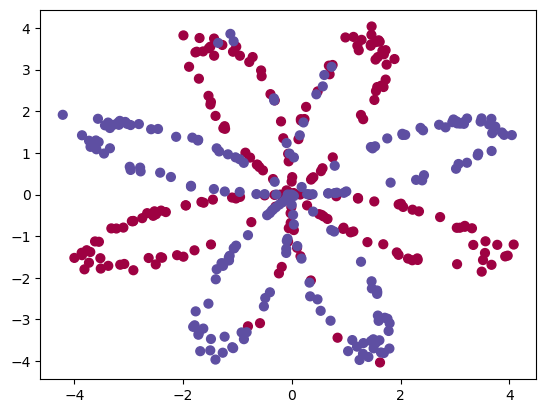

In [5]:
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral)

Observe que este problema é bastante complexo para conseguirmos separar os pontos azuis dos vermelhos com apenas uma linha, como faríamos com um modelo linear simples. Apenas como observação, vamos tentar empregar uma regressão logística:

In [6]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, Y.T)

LogisticRegressionCV()

Taxa de acerto da Regressão Logística: 0.460000 


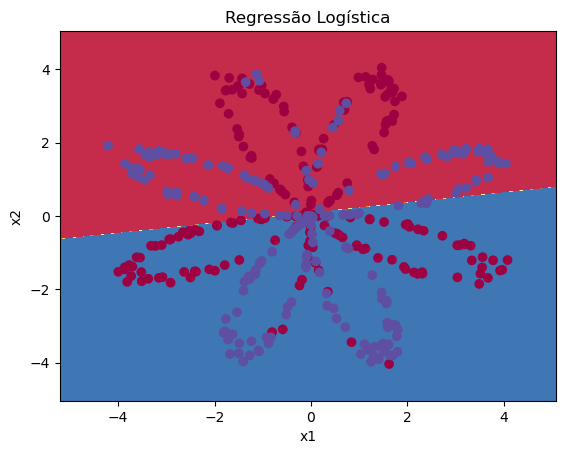

In [7]:
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Regressão Logística")

LR_predictions = clf.predict(X.T)
print ('Taxa de acerto da Regressão Logística: %f ' % float(np.mean(LR_predictions == Y[0])))

Para casos como este precisamos de modelos mais complexos, com superfícies de decisões não lineares. Como as Redes Neurais podem ser vistas com o um conjunto de funções não linearmente combinadas, elas nos possibilitam obter superfícies mais complexas

Vamos treinar o modelo Neural abaixo para vermos se obtemos um resultado melhor

<img src="imagens/simple_nn.png" width="500">

Matematicamente, para um exemplo $x^{(i)}$ temos:

$
z^{[1](i)}=W^{[1]}x^{[1](i)}+b^{[1](i)}\\
a^{[1](i)} = tanh(z^{[1](i)})\\
z^{[2](i)} = W^{[2]}a^{[1](i)}+b^{[2](i)}\\
\hat{y }^{(i)} = a^{[2](i)} = \sigma(z^{[2](i)})\\
\begin{equation}
  y^{(i)}_{predito} ==\left\{
  \begin{array}{@{}ll@{}}
    0, & \text{se}\ a^{[2](i)} > 0.5\\
    1, & \text{caso contrário}
  \end{array}\right.
\end{equation} 
\tag{1}$

Dado os valores preditos, podemos calcular a função de custo por:

$J = - \frac{1}{m} \sum\limits_{i = 0}^{m} \large\left(\small y^{(i)}\log\left(a^{[2] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[2] (i)}\right) \large \right) \small \tag{2}$

O Scikit-learn nos oferece um pacote para trabalharmos com redes Perceptron, para isso definimos a arquitetura da rede como:

In [8]:
clf = MLPClassifier(hidden_layer_sizes=(4, 1), activation='tanh', random_state=42, verbose=True)

In [9]:
clf.fit(X.T, Y.T)

Iteration 1, loss = 0.70299887
Iteration 2, loss = 0.70277825
Iteration 3, loss = 0.70249056
Iteration 4, loss = 0.70223092
Iteration 5, loss = 0.70194007
Iteration 6, loss = 0.70170611
Iteration 7, loss = 0.70144157
Iteration 8, loss = 0.70121450
Iteration 9, loss = 0.70092565
Iteration 10, loss = 0.70071197
Iteration 11, loss = 0.70047543
Iteration 12, loss = 0.70026831
Iteration 13, loss = 0.70004354
Iteration 14, loss = 0.69984422
Iteration 15, loss = 0.69963574
Iteration 16, loss = 0.69943425
Iteration 17, loss = 0.69925511
Iteration 18, loss = 0.69906582
Iteration 19, loss = 0.69888839
Iteration 20, loss = 0.69874448
Iteration 21, loss = 0.69856344
Iteration 22, loss = 0.69840661
Iteration 23, loss = 0.69825968
Iteration 24, loss = 0.69809776
Iteration 25, loss = 0.69795098
Iteration 26, loss = 0.69778982
Iteration 27, loss = 0.69769715
Iteration 28, loss = 0.69752888
Iteration 29, loss = 0.69738079
Iteration 30, loss = 0.69726737
Iteration 31, loss = 0.69714444
Iteration 32, los

/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='tanh', hidden_layer_sizes=(4, 1), random_state=42,
              verbose=True)

Taxa de acerto da Rede Neural: 0.510000 


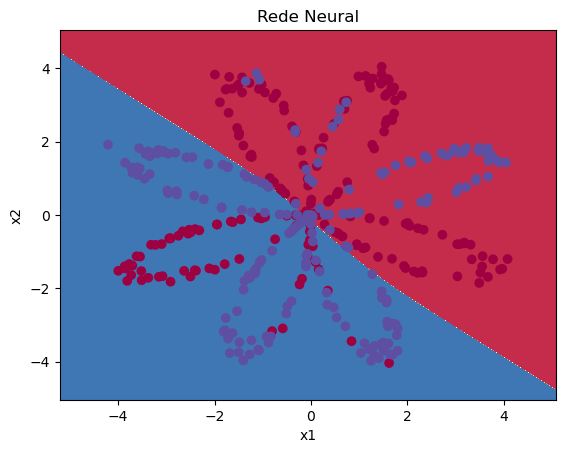

In [10]:
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Rede Neural")

NN_predictions = clf.predict(X.T)
print ('Taxa de acerto da Rede Neural: %f ' % float(np.mean(NN_predictions == Y[0])))

Observe que com este modelo conseguimos construir uma superfície de decisão um pouco "curva" no espaço $R^2$, já que não estamos mais trabalhando com modelos lineares. Com isso aumentamos nossa taxa de acerto

Vamos tentar modelos mais complexos para observarmos esse comportamento

/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Taxa de acerto da Rede Neural: 0.697500 


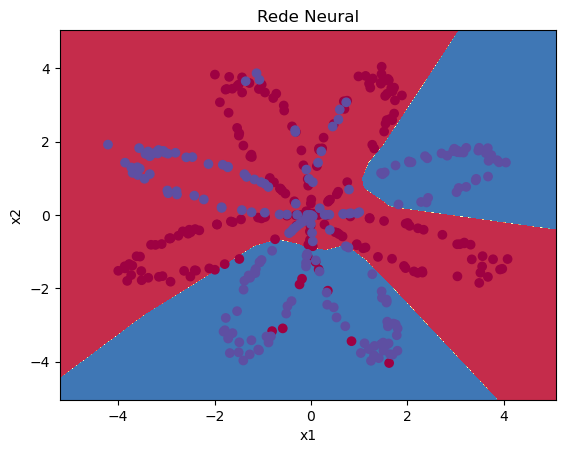

In [11]:
clf = MLPClassifier(hidden_layer_sizes=(10, 8, 4, 2), activation='relu', random_state=42)
clf.fit(X.T, Y.T)
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Rede Neural")

NN_predictions = clf.predict(X.T)
print ('Taxa de acerto da Rede Neural: %f ' % float(np.mean(NN_predictions == Y[0])))

Um hiper parâmetro muito importante a ser configurado em um NN é o learning_rate. Caso ele seja muito baixo, a rede necessitará de muitas interações para convergir (muitas vezes milões), o que inviabiliza o projeto. Porém, se ele for muito alto pode haver um "salto" do mínimo da função pelo gradiente, impossibilitando a convergência do modelo.

<img src="imagens/sgd.gif">

<img src="imagens/sgd_bad.gif">

Vamos testar no nosso exemplo:

Taxa de acerto da Rede Neural: 0.450000 


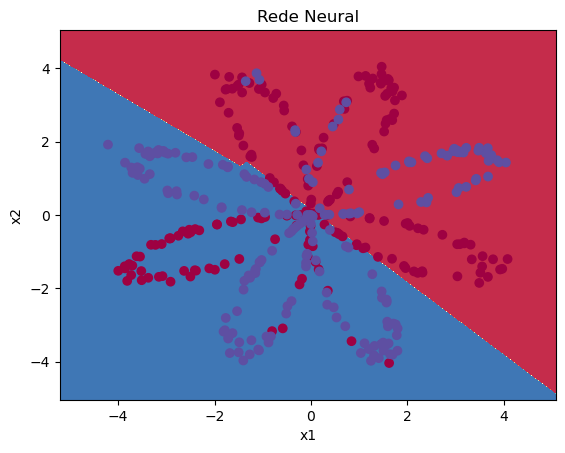

In [12]:
clf = MLPClassifier(hidden_layer_sizes=(4, 4), activation='tanh', random_state=42, learning_rate_init=10.0)
clf.fit(X.T, Y.T)
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Rede Neural")

NN_predictions = clf.predict(X.T)
print ('Taxa de acerto da Rede Neural: %f ' % float(np.mean(NN_predictions == Y[0])))

Observe que mesmo utilizando um modelo mais complexo, a nossa rede não conseguiu convergir para o mínimo de erro

Taxa de acerto da Rede Neural: 0.640000 


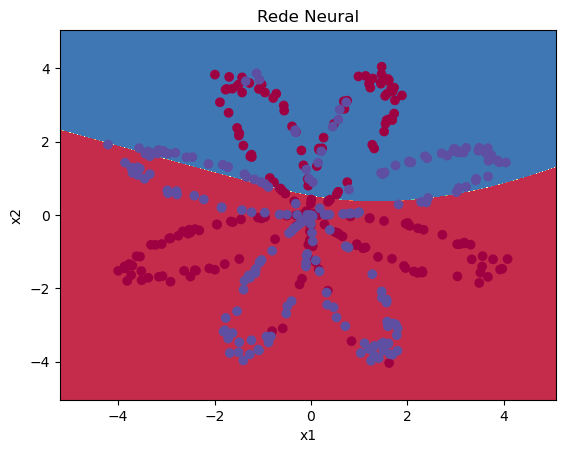

In [13]:
clf = MLPClassifier(hidden_layer_sizes=(4, 4), activation='tanh', random_state=42, learning_rate_init=0.00001)
clf.fit(X.T, Y.T)
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Rede Neural")

NN_predictions = clf.predict(X.T)
print ('Taxa de acerto da Rede Neural: %f ' % float(np.mean(NN_predictions == Y[0])))

O mesmo acontece com uma learning rate muito baixa

/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Taxa de acerto da Rede Neural: 0.552500 


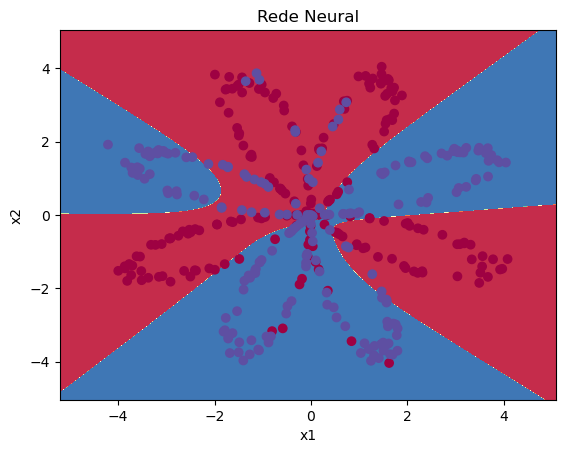

In [14]:
clf = MLPClassifier(hidden_layer_sizes=(4, 4), activation='tanh', random_state=42, learning_rate_init=0.001)
clf.fit(X.T, Y.T)
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Rede Neural")

NN_predictions = clf.predict(X.T)
print ('Taxa de acerto da Rede Neural: %f ' % float(np.mean(NN_predictions == Y[0])))

-> Utulize a arquitetura: (10,8,4,2)
-> learning = 0.001
-> altera o valor de alpha

/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Taxa de acerto da Rede Neural: 0.697500 


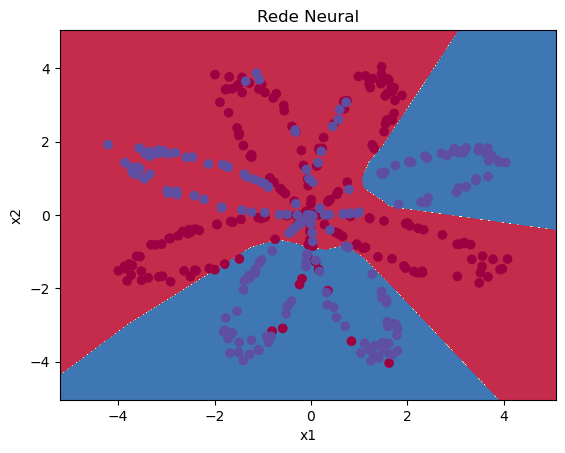

In [15]:
clf = MLPClassifier(hidden_layer_sizes=(10,8,4,2), activation='relu', random_state=42, learning_rate_init=0.001, alpha=0.008)
clf.fit(X.T, Y.T)
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Rede Neural")

NN_predictions = clf.predict(X.T)
print ('Taxa de acerto da Rede Neural: %f ' % float(np.mean(NN_predictions == Y[0])))

Por fim, uma learning rate adequada resulta em um modelo mais preciso

E para prevermos um valor:

In [16]:
clf.predict([[2.5, 0.75]])

array([1], dtype=uint8)

Assim, nosso ponto $(2.5, 0.75)$ é da classe roxo (ou azul)

In [17]:
clf.predict_proba([[2.5, 0.75]])

array([[0.10782326, 0.89217674]])

A probabilidade para a classe vermelha é 0.32 e para a roxa 0.68